In [5]:
from pyspark.sql import SparkSession
import pyspark.sql.functions as f
from pyspark.sql.functions import col
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# Create a spark session (which will run spark jobs)
spark = (
    SparkSession.builder.appName("Project 1")
    .config("spark.sql.repl.eagerEval.enabled", True) 
    .config("spark.sql.parquet.cacheMetadata", "true")
    .config("spark.sql.session.timeZone", "Etc/UTC")
    .getOrCreate()
)

In [7]:
result_df=spark.read.csv("../data/curated/merged_postcode_income.csv", header=True)

In [8]:
agg_data=spark.read.parquet('../data/curated/agg_by_userbiz/')
agg_data

user_id,merchant_abn,count,mean,merch_fraud_prob,con_fraud_prob,state,postcode
13748,17324645993,5,8.426805094403763,NULL,NULL,VIC,3336
13748,77590625261,2,483.1647049459223,NULL,NULL,VIC,3336
13748,22658353530,1,480.74167803248775,NULL,NULL,VIC,3336
13748,81583941068,1,265.5111994935028,NULL,NULL,VIC,3336
13748,27504885147,1,178.90553272015524,NULL,NULL,VIC,3336
13748,25235376304,1,8.196515356719866,NULL,NULL,VIC,3336
13748,35556933338,2,52.92453289004994,NULL,NULL,VIC,3336
13748,42355028515,1,139.3606937259953,NULL,NULL,VIC,3336
13748,40201093869,1,392.3013873909642,NULL,NULL,VIC,3336
13748,32560075533,1,100.15382627842466,NULL,NULL,VIC,3336


In [9]:
user_agg=agg_data.groupBy('user_id').agg(
    f.sum('count').alias('count'),
    f.avg('mean').alias('mean')
)
user_agg

user_id,count,mean
11434,570,178.9302380962375
2250,547,189.53681785930556
18295,551,167.77776770767454
16673,567,180.44532903007322
21787,557,240.93272017709612
20638,555,157.32556234456027
3199,550,154.5173575570771
5241,559,147.4118736754813
1277,540,164.60208797412045
15559,536,178.70874508467202


In [10]:
user_agg_pd=user_agg.toPandas()

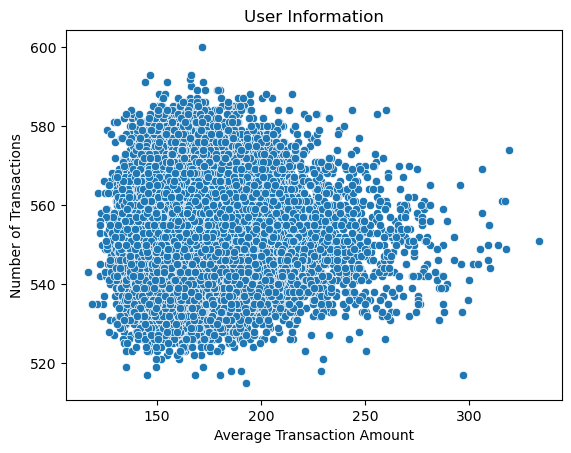

In [11]:
sns.scatterplot(data=user_agg_pd, x='mean', y='count')
plt.xlabel('Average Transaction Amount')
plt.ylabel('Number of Transactions')
plt.title('User Information')
plt.show()

In [12]:
biz_agg=agg_data.groupBy('merchant_abn').agg(
    f.sum('count').alias('count'),
    f.avg('mean').alias('mean')
)
biz_agg

merchant_abn,count,mean
73256306726,5260,283.41027481980694
15613631617,1783,303.1120120913352
34440496342,215,90.35050618004644
83412691377,14288,34.87049873624944
73841664453,959,87.20663330574303
19839532017,726,157.0
12516851436,203,144.4963278179552
35344855546,1518,87.75188757487723
48214071373,540,300.28802060321584
60654402457,199,85.65342685212403


In [13]:
biz_agg_pd=biz_agg.toPandas()

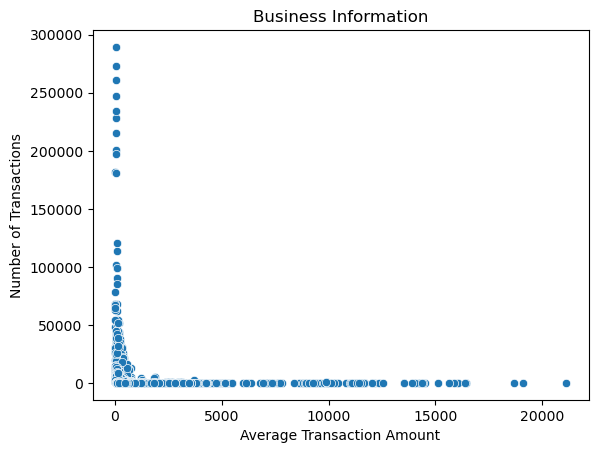

In [14]:
sns.scatterplot(data=biz_agg_pd, x='mean', y='count')
plt.xlabel('Average Transaction Amount')
plt.ylabel('Number of Transactions')
plt.title('Business Information')
plt.show()

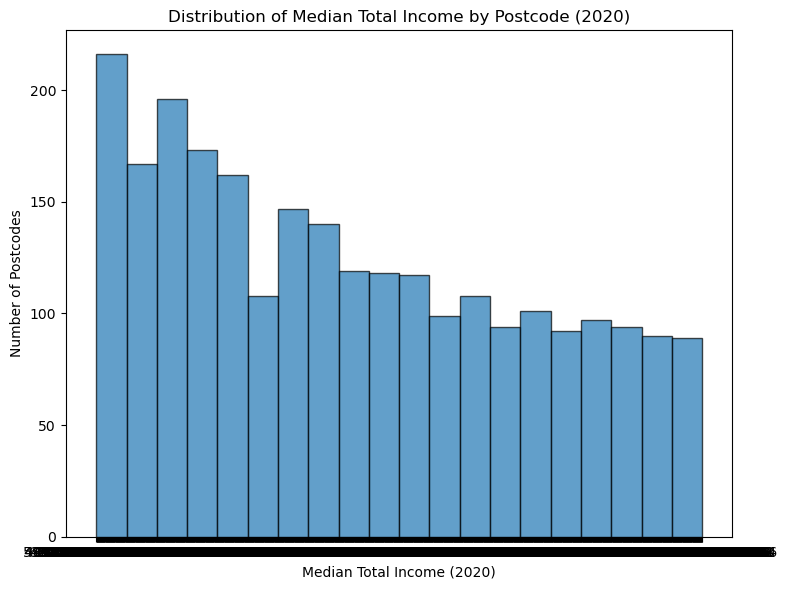

In [15]:
pdf = result_df.toPandas()
# Drop missing values (important to avoid errors)
pdf = pdf.dropna(subset=["median_total_income_2020"])

# Histogram
plt.figure(figsize=(8, 6))
plt.hist(pdf["median_total_income_2020"], bins=20, edgecolor="black", alpha=0.7)

plt.xlabel("Median Total Income (2020)")
plt.ylabel("Number of Postcodes")
plt.title("Distribution of Median Total Income by Postcode (2020)")
plt.tight_layout()
plt.show()

In [ ]:
# Drop missing values
pdf = pdf.dropna(subset=["median_total_income_2020"])

# Define bin edges in 10k intervals
min_val = float(pdf["median_total_income_2020"].min())
max_val = float(pdf["median_total_income_2020"].max())

# Start from the nearest 10k below min, go to nearest 10k above max
bins = np.arange((min_val // 10000) * 10000, ((max_val // 10000) + 1) * 10000 + 1, 10000)

# Create labels like "30k-40k", "40k-50k", etc.
labels = [f"{int(bins[i]/1000)}k-{int(bins[i+1]/1000)}k" for i in range(len(bins)-1)]

# Categorize incomes into bins
pdf["income_bin"] = pd.cut(pdf["median_total_income_2020"], bins=bins, labels=labels, right=False)

# Count how many postcodes fall into each bin
bin_counts = pdf["income_bin"].value_counts().sort_index()

# Bar chart
plt.figure(figsize=(10, 6))
bin_counts.plot(kind="bar", color="skyblue", edgecolor="black")

plt.xlabel("Income Bin")
plt.ylabel("Number of Postcodes")
plt.title("Postcodes Grouped into 10k Income Bins (2020)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


ValueError: Bin labels must be one fewer than the number of bin edges